# Deep Crossentropy method

In this section we'll extend your CEM implementation with neural networks! You will train a multi-layer neural network to solve simple continuous state space games. __Please make sure you're done with tabular crossentropy method from the previous notebook.__

![img](https://watanimg.elwatannews.com/old_news_images/large/249765_Large_20140709045740_11.jpg)



In [50]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

In [51]:
# Install gymnasium if you didn't
!pip install "gymnasium[toy_text,classic_control]"

state vector dim = 4
n_actions = 2


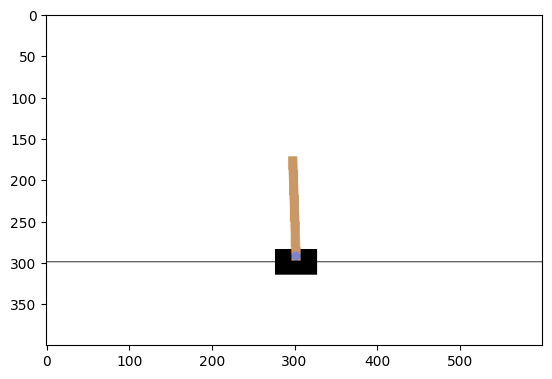

In [52]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# if you see "<classname> has no attribute .env", remove .env or update gym
env = gym.make("CartPole-v0", render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)

env.close()

# Neural Network Policy

For this assignment we'll utilize the simplified neural network implementation from __[Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)__. Here's what you'll need:

* `agent.partial_fit(states, actions)` - make a single training pass over the data. Maximize the probability of :actions: from :states:
* `agent.predict_proba(states)` - predict probabilities of all actions, a matrix of shape __[len(states), n_actions]__


In [53]:
from sklearn.neural_network import MLPClassifier

agent = MLPClassifier(
    hidden_layer_sizes=(20, 20),
    activation="tanh",
)

# initialize agent to the dimension of state space and number of actions
agent.partial_fit([env.reset()[0]] * n_actions, range(n_actions), classes=range(n_actions))


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(20, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


In [54]:
def generate_session(env, agent, t_max=1000):
    """
    Play a single game using agent neural network.
    Terminate when game finishes or after :t_max: steps
    """
    states, actions = [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):

        # use agent to predict a vector of action probabilities for state :s:
        probs = agent.predict_proba([s])[0]

        assert probs.shape == (env.action_space.n,), "make sure probabilities are a vector (hint: np.reshape)"

        # use the probabilities you predicted to pick an action
        # sample proportionally to the probabilities, don't just take the most likely action
        a = np.random.choice(np.arange(env.action_space.n), p=probs)
        # ^-- hint: try np.random.choice

        new_s, r, terminated, truncated, _ = env.step(a)

        # record sessions like you did before
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward


In [55]:
dummy_states, dummy_actions, dummy_reward = generate_session(env, agent, t_max=5)
print("states:", np.stack(dummy_states))
print("actions:", dummy_actions)
print("reward:", dummy_reward)


states: [[-0.04412423  0.01667667  0.0457863   0.02317044]
 [-0.0437907  -0.17907098  0.04624971  0.32994065]
 [-0.04737212 -0.37481976  0.05284852  0.63684237]
 [-0.05486852 -0.57063735  0.06558537  0.9456889 ]
 [-0.06628127 -0.76657844  0.08449914  1.2582369 ]]
actions: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1)]
reward: 5.0


### CEM steps
Deep CEM uses exactly the same strategy as the regular CEM, so you can copy your function code from previous notebook.

The only difference is that now each observation is not a number but a `float32` vector.

In [56]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """

    reward_threshold = np.percentile(rewards_batch, percentile)
    if (np.array(rewards_batch) == rewards_batch[0]).all():
        reward_threshold -= 1e-8
    elite_states = []
    elite_actions = []
    for states, actions, reward in zip(states_batch, actions_batch, rewards_batch, strict=True):
        if reward > reward_threshold:
            elite_states.extend(states)
            elite_actions.extend(actions)
    return elite_states, elite_actions

# Training loop
Generate sessions, select N best and fit to those.

In [57]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range, bins=50)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    plt.show()


mean reward = 224.770, threshold=260.000


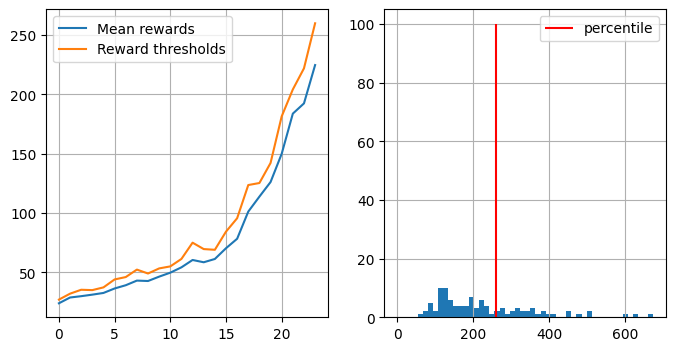

You Win! You may stop training now via KeyboardInterrupt.


KeyboardInterrupt: 

In [58]:
n_sessions = 100
percentile = 70
log = []

for i in range(100):
    # generate new sessions
    sessions = [generate_session(env, agent) for _ in range(n_sessions)]

    states_batch, actions_batch, rewards_batch = zip(*sessions)

    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)

    agent.partial_fit(elite_states, elite_actions)

    show_progress(
        rewards_batch, log, percentile, reward_range=[0, np.max(rewards_batch)]
    )

    if np.mean(rewards_batch) > 190:
        print("You Win! You may stop training now via KeyboardInterrupt.")


# Results

In [10]:
# # Record sessions

# from gymnasium.wrappers import RecordVideo

# with RecordVideo(
#     env=gym.make("CartPole-v0", render_mode="rgb_array"),
#     video_folder="./videos",
#     episode_trigger=lambda episode_number: True,
# ) as env_monitor:
#     sessions = [generate_session(env_monitor, agent) for _ in range(100)]


In [11]:
# # Show video. This may not work in some setups. If it doesn't
# # work for you, you can download the videos and view them locally.

# from pathlib import Path
# from base64 import b64encode
# from IPython.display import HTML

# video_paths = sorted([s for s in Path("videos").iterdir() if s.suffix == ".mp4"])
# video_path = video_paths[-1]  # You can also try other indices

# if "google.colab" in sys.modules:
#     # https://stackoverflow.com/a/57378660/1214547
#     with video_path.open("rb") as fp:
#         mp4 = fp.read()
#     data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
# else:
#     data_url = str(video_path)

# HTML(
#     """
# <video width="640" height="480" controls>
#   <source src="{}" type="video/mp4">
# </video>
# """.format(
#         data_url
#     )
# )


# Homework part I

### Tabular crossentropy method

You may have noticed that the taxi problem quickly converges from -100 to a near-optimal score and then descends back into -50/-100. This is in part because the environment has some innate randomness. Namely, the starting points of passenger/driver change from episode to episode.

### Tasks
- __1.1__ (2 pts) Find out how the algorithm performance changes if you use a different `percentile` and/or `n_sessions`. Provide here some figures so we can see how the hyperparameters influence the performance.
- __1.2__ (1 pts) Tune the algorithm to end up with positive average score.

It's okay to modify the existing code.


## Solution

Since the problem is that agent sees only "good" scenarios during its training, my first idea was to lower percentile and increase the number of sessions. When I did that (set percentile=0.3, n_sessions=500), mean reward reaches positive value (about 1) after some iterations successfully. Then I tried percentile 0.1, and it reached about 5-7, but it took a lot of iterations. That's because with low percentile it learns slower, so it takes more time to go up from -700 up to 0.

Here's the actual graph which shows the effect of percentile:
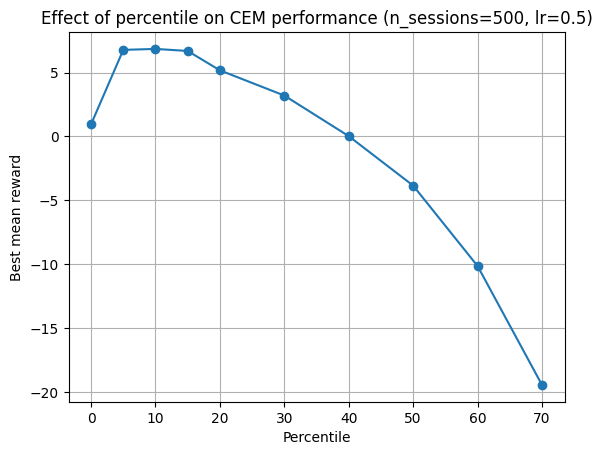

Apparently, percentile=0.1 is the best for final steps to converge to the best strategy. But for early steps higher percentile is preferred to speed up the process.

So my final solution was to do some scheduling, vary learning rate and user more sessions (800):
```
start:          lr=0.7, percentile=0.7
reward > -100:  lr=0.5, percentile=0.3
reward > 0:     lr=0.2, percentile=0.1
```

Here's the results I got:
```
Iter 0: lr=0.70, percentile=70, mean=-765.08
Iter 10: lr=0.50, percentile=30, mean=-36.61
Iter 20: lr=0.20, percentile=10, mean=0.80
Iter 30: lr=0.20, percentile=10, mean=3.45
Iter 40: lr=0.20, percentile=10, mean=4.21
Iter 50: lr=0.20, percentile=10, mean=4.93
Iter 60: lr=0.20, percentile=10, mean=5.51
Iter 70: lr=0.20, percentile=10, mean=6.02
Iter 80: lr=0.20, percentile=10, mean=6.34
Iter 90: lr=0.20, percentile=10, mean=6.47
Iter 100: lr=0.20, percentile=10, mean=7.06
Iter 110: lr=0.20, percentile=10, mean=6.41
Iter 120: lr=0.20, percentile=10, mean=7.08
Iter 130: lr=0.20, percentile=10, mean=6.83
Iter 140: lr=0.20, percentile=10, mean=6.50
Early stopping at iter 147, mean=7.07
Best mean reward: 7.21
```

Best policy was pickled.

# Homework part II

### Deep crossentropy method

By this moment, you should have got enough score on [CartPole-v0](https://gymnasium.farama.org/environments/classic_control/cart_pole/) to consider it solved (see the link). It's time to try something harder.

* if you have any trouble with CartPole-v0 and feel stuck, feel free to ask us or your peers for help.

### Tasks

* __2.1__ (3 pts) Pick one of environments: `MountainCar-v0` or `LunarLander-v2`.
  * For MountainCar, get average reward of __at least -150__
  * For LunarLander, get average reward of __at least +50__

See the tips section below, it's kinda important.
__Note:__ If your agent is below the target score, you'll still get some of the points depending on the result, so don't be afraid to submit it.
  
  
* __2.2__ (up to 6 pts) Devise a way to speed up training against the default version
  * Obvious improvement: use [`joblib`](https://joblib.readthedocs.io/en/latest/). However, note that you will probably need to spawn a new environment in each of the workers instead of passing it via pickling. (2 pts)
  * Try re-using samples from 3-5 last iterations when computing threshold and training. (2 pts)
  * Obtain __-100__ at `MountainCar-v0` or __+200__ at `LunarLander-v2` (2 pts). Feel free to experiment with hyperparameters, architectures, schedules etc.
  
__Please list what you did in Anytask submission form__. This reduces probability that somebody misses something.
  
  
### Tips
* Gymnasium pages: [MountainCar](https://gymnasium.farama.org/environments/classic_control/mountain_car/), [LunarLander](https://gymnasium.farama.org/environments/box2d/lunar_lander/)
* Sessions for MountainCar may last for 10k+ ticks. Make sure ```t_max``` param is at least 10k.
 * Also it may be a good idea to cut rewards via ">" and not ">=". If 90% of your sessions get reward of -10k and 10% are better, than if you use percentile 20% as threshold, R >= threshold __fails to cut off bad sessions__ while R > threshold works alright.
* _issue with gym_: Some versions of gym limit game time by 200 ticks. This will prevent cem training in most cases. Make sure your agent is able to play for the specified __t_max__, and if it isn't, try `env = gym.make("MountainCar-v0").env` or otherwise get rid of TimeLimit wrapper.
* If you use old _swig_ lib for LunarLander-v2, you may get an error. See this [issue](https://github.com/openai/gym/issues/100) for solution.
* If it doesn't train, it's a good idea to plot reward distribution and record sessions: they may give you some clue. If they don't, call course staff :)
* 20-neuron network is probably not enough, feel free to experiment.

You may find the following snippet useful:

## Отчёт

Здесь у меня получилось обучить `mountain_car` до -100, однако это заняло много-много итераций, с разными гиперпараметрами, разными размерами моделей, разными параметрами обучения, и.т.д. поэтому какого-то лаконичного кода "запустить это на 1000 итераций и будет -100" у меня не получилось, и поэтому я объясню текстом, что я делал, что работало, а что нет.

В качестве модели я сначала пробовал полносвязные нейросети со слоями [2, 8, 16, 16, 8, 3], [2, 128, 128, 3], [2, 32, 64, 64, 32, 3], но в итоге, в самом конце я взял [2, 16, 16, 3] и с ней все отлично получилось обучить, ну а ясное дело, что меньше параметров - лучше, если модель не недообучается (и по скорости, и вероятность переообучения меньше). Поэтому я думаю можно было с самого начала взять [2, 16, 16, 3] и все так же сработало бы.

Первый шаг в обучении было научить модель хотя бы водить машину так, чтобы она двигалась и чтобы игра заканчивалась до 10000 шагов. Необученная нейросеть обычно выдает примерно равномерное распределение на выходе, поэтому когда такая модель играет в `mountain_car`, по сути она рандомно выбирает действие на каждом тике, и в итоге в среднем машина никуда не двигается (как например если в GTA очень быстро чередовать кнопки W и S то машина просто не будет ехать). Поэтому если пытаться рандомно выбить успешные сессии с такой моделью, то это займет очень много времени.

Поэтому я сделал 2 трюка: 
1. Раз на начальных стадиях обучения модель выбирает действие рандомно, то нам и модель не нужна чтобы генерировать сессии - можно просто поставить туда рандомайзер. Таким образом мы не будем тратить время на инференс нейросети (модель маленькая, но все равно рандомайзер быстрее, и генерация сессий стала идти в 2-3 раза быстрее)
2. Представим себе обученную модель для этой игры. Скорее всего если вход не сильно отличается, то и выход не будет сильно отличаться. Так же скорее всего в большинстве позиций модель будет уверена в своем выборе и её выход будет иметь маленькую энтропию (уверенность в одном ответе). Так вела бы себя идеальная модель. А раз мы хотим обучить такую модель, то можно немного поменять генерацию сессий - будем рандомно выбирать действие, а потом 10 тиков повторять его, потому что в окрестности 10 тиков позиция+скорость тоже в небольшой окрестности, поэтому и выходы модели должны быть в небольшой окрестности, и раз мы предполагаем, что модель часто уверена в своем ответе, то она будет склонна выбирать один и тот же ответ на последовательных тиках. Таким образом мы уберем значительную часть шума в наших сессиях, когда действие по сути рандомное и вообще не зависит от входа (успешные сессии это сессии где каким-то чудом рандом в среднем немного склонялся в сторону правильного ответа, но шума все равно очень уж много), а мы пытаемся обучить на этом модель.

Это может показаться немного читерным, потому что мы используем знания об окружении (то что нужно повторять действия в течении нескольких тиков), ведь могла бы быть игра, где наоборот надо чередовать действия, но я считаю, что раз уж мы знаем, что игра это аппроксимация непрерывной игры (где бы не было тиков, то есть бесконечно малые тики), то мои предположения вполне честные.

В общем, с этими улучшениями можно генерировать более качественные сессии (меньше шума) более быстро (не использовать модель вообще). На самом деле это улучшение с повторением хода 10 тиков значительно приближает нас к правильной стратегии, потому что количество успешных сессий (>-10k) значительно возрастает, поэтому обучаться становиться гораздо проще. Поэтому я и назвал это немного читерным, но изначально я этого не задумывал, все таки так совпало))

Теперь на этих сессиях можно уже начинать обучать модель, брать перцентиль около 60-80. Таким образом модель вполне легко обучается заканчивать игру до -10000 шагов, а потом доходит до -2000.

Дальше можно уже начинать использовать модель для генерации сессий, Так мы медленно но верно доходим до примерно -300. Дальше уже начинаются некоторые танцы с бубном (с гиперпараметрами): нужно смотреть на гистограммы, делать какие-то умозаключения и на этом основывать выбор перцентиля (про это еще расскажу чуть позже). Так же я пробовал менять `learning_rate`, пробовать увеличивать `max_iter` у `MLPClassifier` (не совсем успешно, потому что если обучать до сходимости на каком-то конкретном наборе сессий, то получается фигня), менять оптимизатор с `sgd` на `adam` и обратно (я начинал с `sgd` без какой-либо идеи, просто в каких-то задачах `sgd` с моментами справляется лучше адама, например на некоторых image classification задачах, поэтому я подумал что стоит попробовать оба), копить элит с последних нескольких шагов (по сути это просто увеличивает количество сэмплов для обучения, поэтому если мы и так генерируем достаточное количество сессий, то я думаю это не сильно помогает именно в качестве). 

Еще я добавил `joblib` чтобы распараллелить генерацию сессий (к сожалению только на этом моменте про это вспомнил), и это ускорило генерацию в несколько раз.

Такими темпами я дошел примерно до -125, дальше был некоторый ступор, потому что обучить выше не получалось. В итоге я перешел на меньшую модель (была вроде [2, 32, 64, 64, 32, 3], взял [2, 16, 16, 3]) - когда я менял модели то я просто генерировал 10000 сессий с обученной моделью, брал какой-то перцентиль элит (от 20 до 80), и обучал до сходимости новую модель на этих элитах, и таким образом переходить на другую модель можно очень быстро, когда есть уже сколько-то обученная другая модель.

Дальше я уменьшил `learning_rate` до 0.0002, копил элит с последних 8 шагов, и поставил перцентиль в 60: до этого я пытался брать наоборот более большие перцентили типа 80-90-95, потому что я думал, что нам здесь нужно именно смотреть на те сессии, которые >-100, однако я объяснил выбор 60 так: если посмотреть на график реворда у модели с `mean_reward=-125` (см. картинку), то видно что там есть 2-3 пика, где один пик за -100, а остальные два от -400 до -150. Высокие перцентили отрезают часть самого правого пика, однако если так подумать, то пики это наверное какие-то разные виды начальных состояний, и просто в каких-то начальных состояниях дойти до финиша проще за 100 шагов, чем в других. Если обучить модель только на этих состояниях, то левые пики вряд ли сдвинутся. Это похоже на проблему в такси, где брать перцентиль >=50 уже плохо, потому что там начальные состояния могут сильно отличаться, и обучаться только на удачных - плохая идея. Здесь все не так критично, но все равно проблема есть. Поэтому я взял 60, которые как раз обрезает второй пик чуть-чуть справа, то есть по идее он должен брать сессии в "неудачных начальных состояниях", но где модель справилась лучше чем обычно.

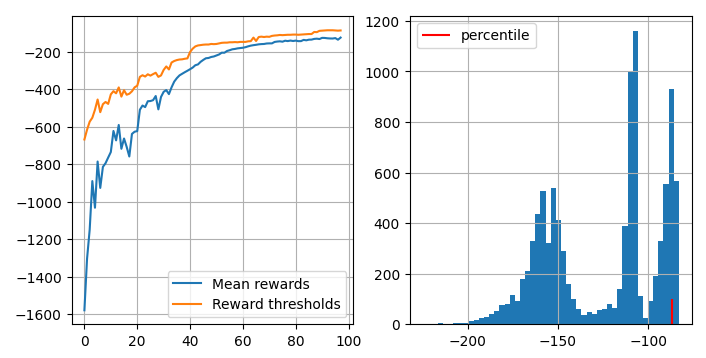

С перцентилем в 60 модель уже достаточно быстро дошла до -100 (см. картинку): все равно остается 2 пика, но левый пик значительно приближается к -100, и среднее получается как раз в районе -100 и -99.

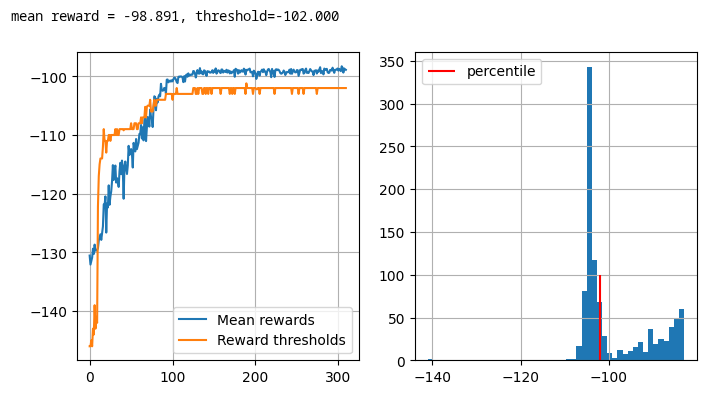

В общем много разных экспериментов, но в итоге есть обученный агент на -100. Дальше идут какие-то куски кода, которые я использовал, если вдруг нужно.

state_dim=2, n_actions=np.int64(3)


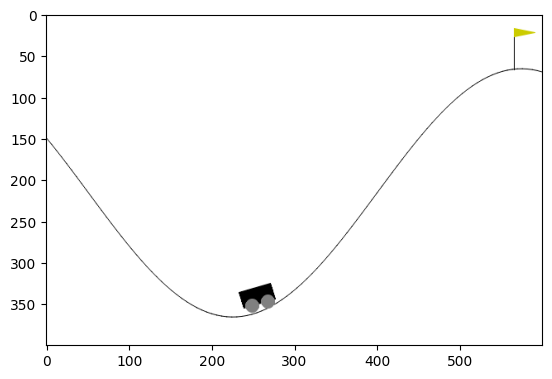

In [20]:
env = gym.make("MountainCar-v0", render_mode="rgb_array").env

n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

print(f"{state_dim=}, {n_actions=}")

env.reset()
plt.imshow(env.render())
env.close()

In [21]:
from sklearn.neural_network import MLPClassifier
from functools import partial

agent = MLPClassifier(
    hidden_layer_sizes=(8, 16, 16, 8),
    activation="relu",
    max_iter=1,
    warm_start=True,
    solver="sgd",
)

agent.partial_fit(
    [env.reset()[0]] * n_actions, range(n_actions), classes=range(n_actions)
)


def get_probs_(agent, s):
    return agent.predict_proba([s])[0]


get_probs = partial(get_probs_, agent)
agent

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(8, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'sgd'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


In [22]:
import warnings

warnings.filterwarnings("ignore")

In [23]:
from tqdm.notebook import tqdm

def generate_session(env, probs_f, t_max=1000):
    states, actions = [], []
    total_reward = 0
    s, _ = env.reset()
    for t in range(t_max):
        a = np.random.choice(np.arange(env.action_space.n), p=probs_f(s))
        new_s, r, terminated, truncated, _ = env.step(a)
        states.append(s)
        actions.append(a)
        total_reward += r
        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward

In [24]:
log = []


def train(agent, probs_f, n_sessions, percentile):
    sessions = [
        generate_session(env, probs_f, t_max=10000) for _ in tqdm(range(n_sessions))
    ]
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    elite_states, elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, percentile
    )
    agent.partial_fit(elite_states, elite_actions)
    show_progress(rewards_batch, log, percentile, reward_range=[-20000, 0])

In [25]:
def delay_action(probs_f, wait_steps=500):
    i = 0
    probs = np.ones(env.action_space.n) / env.action_space.n

    def new_probs_f(s):
        nonlocal i, probs
        if i % wait_steps == 0:
            action = np.random.choice(np.arange(env.action_space.n), p=probs_f(s))
            probs = np.zeros(env.action_space.n)
            probs[action] = 1
        i += 1
        return probs

    return new_probs_f

In [17]:
uniform_probs = np.ones(env.action_space.n) / env.action_space.n

sessions = [
    generate_session(
        env, delay_action(lambda s: uniform_probs, wait_steps=10), t_max=10000
    )
    for _ in tqdm(range(5000))
]
states_batch, actions_batch, rewards_batch = zip(*sessions)
elite_states, elite_actions = select_elites(
    states_batch, actions_batch, rewards_batch, 0.3
)

  0%|          | 0/5000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [28]:
elite_states, elite_actions = select_elites(
    states_batch, actions_batch, rewards_batch, 0.9
)

In [30]:
agent.max_iter = 200
agent.fit(elite_states, elite_actions)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(8, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'sgd'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


mean reward = -591.360, threshold=-390.900


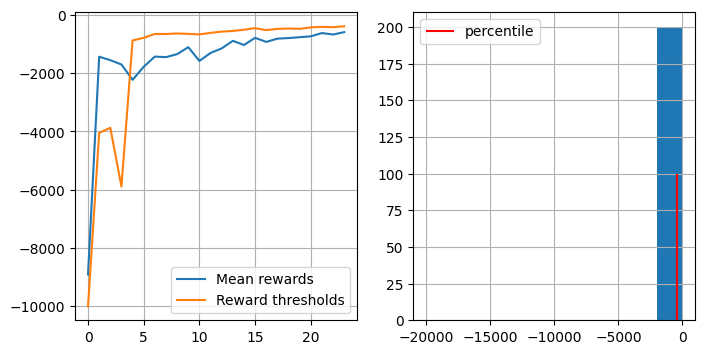

In [37]:
agent.learning_rate_init = 0.001
agent.max_iter = 1

elite_states = []
elite_actions = []

for _ in tqdm(range(20)):
    sessions = [
        generate_session(env, get_probs, t_max=10000) for _ in tqdm(range(200))
    ]
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    new_elite_states, new_elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, 90
    )
    elite_states.extend(new_elite_states)
    elite_actions.extend(new_elite_actions)
    agent.partial_fit(elite_states, elite_actions)
    show_progress(rewards_batch, log, 90, reward_range=[-20000, 0])
    agent.learning_rate_init *= 0.9

mean reward = -405.060, threshold=-279.000


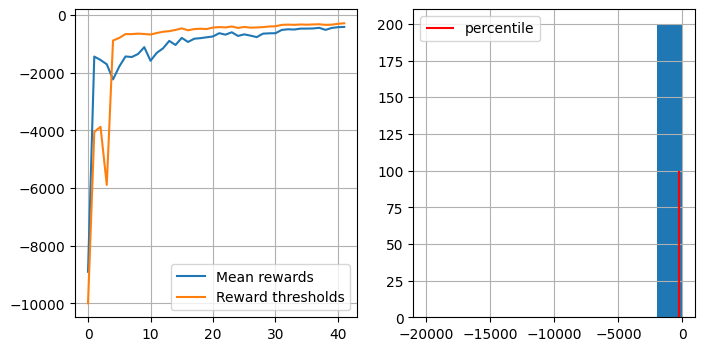

  0%|          | 0/200 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [38]:
agent.learning_rate_init = 0.001
agent.max_iter = 3

elite_states = []
elite_actions = []

for _ in tqdm(range(20)):
    sessions = [
        generate_session(env, get_probs, t_max=10000) for _ in tqdm(range(200))
    ]
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    new_elite_states, new_elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, 90
    )
    elite_states.extend(new_elite_states)
    elite_actions.extend(new_elite_actions)
    agent.partial_fit(elite_states, elite_actions)
    show_progress(rewards_batch, log, 90, reward_range=[-20000, 0])
    agent.learning_rate_init *= 0.9

mean reward = -301.973, threshold=-236.000


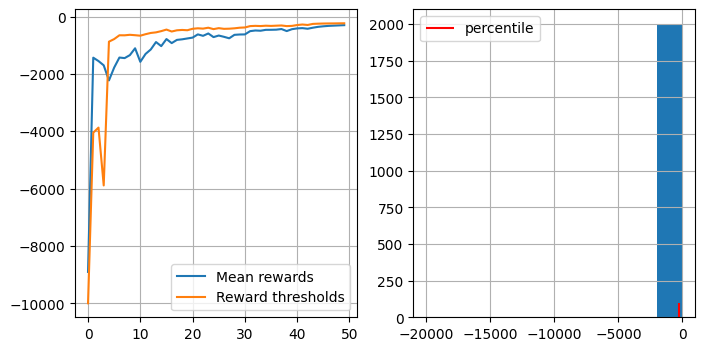

  0%|          | 0/2000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [39]:
agent.learning_rate_init = 0.002
agent.max_iter = 3

elite_states = []
elite_actions = []

for _ in tqdm(range(10)):
    sessions = [
        generate_session(env, get_probs, t_max=10000) for _ in tqdm(range(2000))
    ]
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    new_elite_states, new_elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, 90
    )
    elite_states.extend(new_elite_states)
    elite_actions.extend(new_elite_actions)
    agent.partial_fit(elite_states, elite_actions)
    show_progress(rewards_batch, log, 90, reward_range=[-20000, 0])
    agent.learning_rate_init *= 0.9

mean reward = -225.805, threshold=-160.000


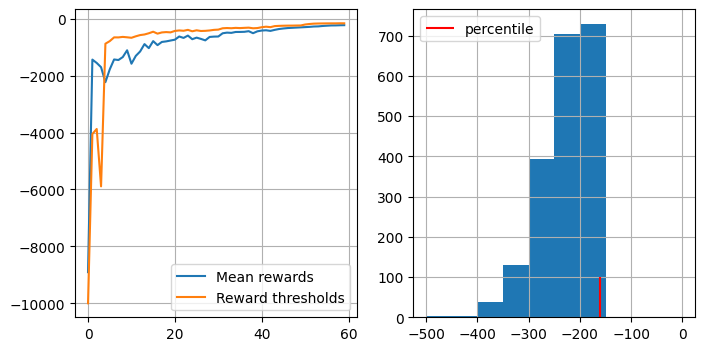

In [40]:
agent.learning_rate_init = 0.002
agent.max_iter = 3

elite_states = []
elite_actions = []

for _ in tqdm(range(10)):
    sessions = [
        generate_session(env, get_probs, t_max=10000) for _ in tqdm(range(2000))
    ]
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    new_elite_states, new_elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, 95
    )
    elite_states.extend(new_elite_states)
    elite_actions.extend(new_elite_actions)
    agent.partial_fit(elite_states, elite_actions)
    show_progress(rewards_batch, log, 95, reward_range=None)
    agent.learning_rate_init *= 0.9

In [41]:
import pickle

with open("mountain_car.pkl", "wb") as f:
    pickle.dump(agent, f)

mean reward = -180.852, threshold=-148.000


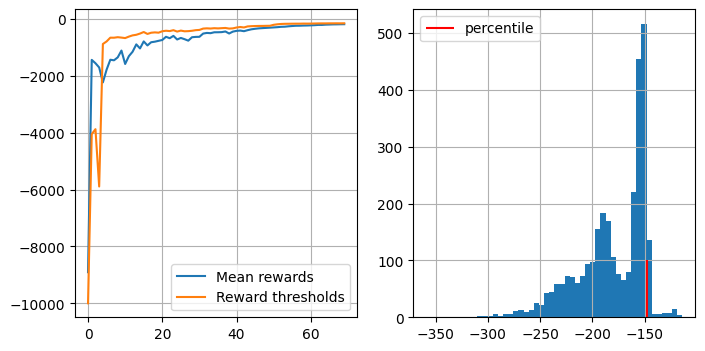

In [44]:
agent.learning_rate_init = 0.002
agent.max_iter = 3

elite_states = []
elite_actions = []

for _ in tqdm(range(10)):
    sessions = [
        generate_session(env, get_probs, t_max=10000) for _ in tqdm(range(3000))
    ]
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    new_elite_states, new_elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, 95
    )
    elite_states.extend(new_elite_states)
    elite_actions.extend(new_elite_actions)
    agent.partial_fit(elite_states, elite_actions)
    show_progress(rewards_batch, log, 95, reward_range=None)
    agent.learning_rate_init *= 0.9

mean reward = -179.247, threshold=-148.000


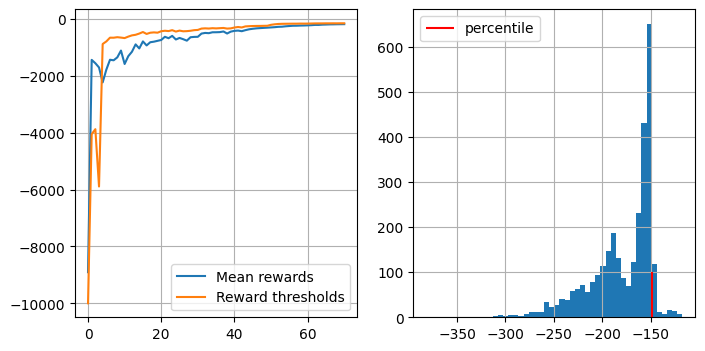

  0%|          | 0/3000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [45]:
agent.learning_rate_init = 0.002
agent.max_iter = 3

elite_states = []
elite_actions = []

for _ in tqdm(range(10)):
    sessions = [
        generate_session(env, get_probs, t_max=10000) for _ in tqdm(range(3000))
    ]
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    new_elite_states, new_elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, 95
    )
    elite_states.extend(new_elite_states)
    elite_actions.extend(new_elite_actions)
    agent.partial_fit(elite_states, elite_actions)
    show_progress(rewards_batch, log, 95, reward_range=None)
    agent.learning_rate_init *= 0.9

In [26]:
import joblib

def generate_sessions(n_sessions, agent, n_jobs=7):
    jobs = []
    for _ in range(n_jobs):
        env = gym.make("MountainCar-v0", render_mode="rgb_array").env

        def job(agent):
            return [
                generate_session(env, partial(get_probs_, agent), t_max=10000) for _ in range(n_sessions // n_jobs)
            ]

        jobs.append(joblib.delayed(job)(agent))

    return sum(joblib.Parallel(n_jobs=n_jobs)(jobs), [])

mean reward = -126.518, threshold=-88.000


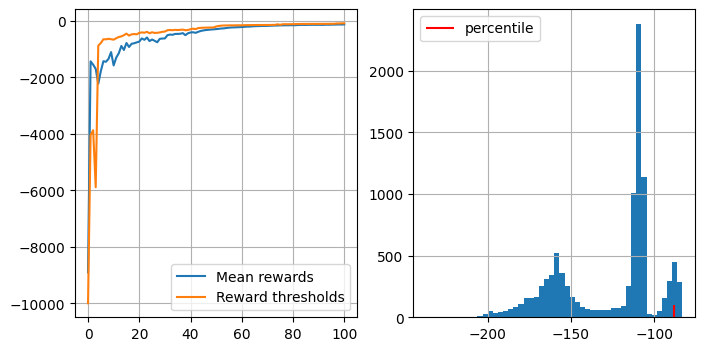

In [ ]:
for _ in range(3):
    agent.learning_rate_init = 0.001

    elite_states = []
    elite_actions = []

    for _ in tqdm(range(10)):
        sessions = generate_sessions(10000, agent)
        states_batch, actions_batch, rewards_batch = zip(*sessions)
        new_elite_states, new_elite_actions = select_elites(
            states_batch, actions_batch, rewards_batch, 95
        )
        elite_states.extend(new_elite_states)
        elite_actions.extend(new_elite_actions)
        agent.partial_fit(elite_states, elite_actions)
        show_progress(rewards_batch, log, 95, reward_range=None)
        agent.learning_rate_init *= 0.9

mean reward = -132.187, threshold=-86.000


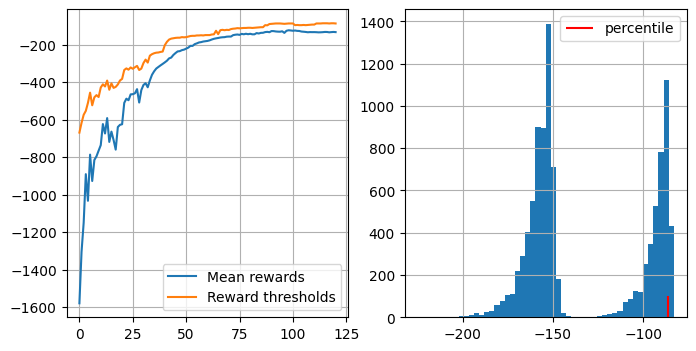

In [65]:
agent.learning_rate_init = 0.001
agent.max_iter = 1

elite_states = []
elite_actions = []

for i in tqdm(range(10)):
    sessions = generate_sessions(10000, agent)
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    new_elite_states, new_elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, 95
    )
    elite_states.extend(new_elite_states)
    elite_actions.extend(new_elite_actions)
    agent.partial_fit(elite_states, elite_actions)
    show_progress(rewards_batch, log, 95, reward_range=None)
    agent.max_iter *= 2
    agent.learning_rate_init *= 0.8

In [30]:
with open("mountain_car_124.pkl", "rb") as f:
    agent = pickle.load(f)

mean reward = -123.906, threshold=-107.000


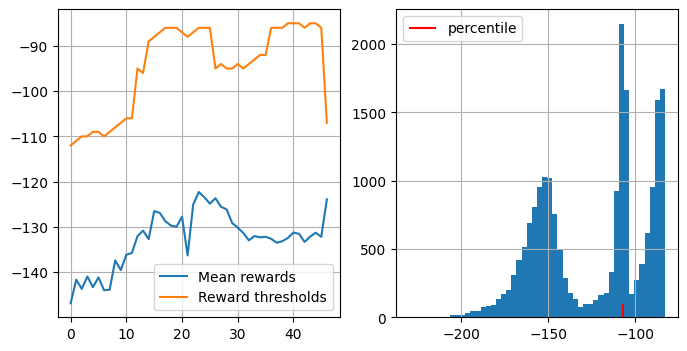

In [68]:
agent.learning_rate_init = 0.0004
agent.max_iter = 200

sessions = generate_sessions(20000, agent)
states_batch, actions_batch, rewards_batch = zip(*sessions)
elite_states, elite_actions = select_elites(
    states_batch, actions_batch, rewards_batch, 60
)
agent.partial_fit(elite_states, elite_actions)
show_progress(rewards_batch, log, 60, reward_range=None)

mean reward = -130.993, threshold=-86.000


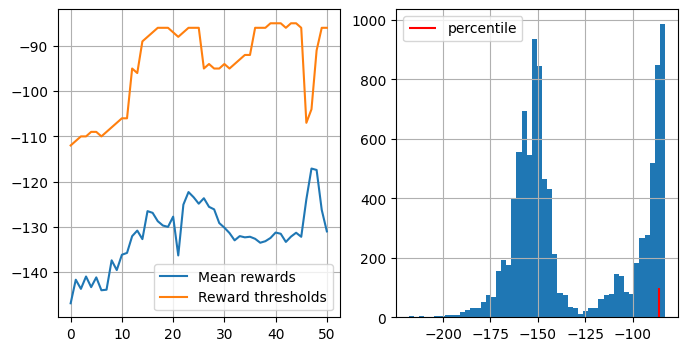

In [70]:
agent.learning_rate_init = 0.0002
agent.max_iter = 200

sessions = generate_sessions(10000, agent)
states_batch, actions_batch, rewards_batch = zip(*sessions)
elite_states, elite_actions = select_elites(
    states_batch, actions_batch, rewards_batch, 90
)
agent.partial_fit(elite_states, elite_actions)
show_progress(rewards_batch, log, 90, reward_range=None)

In [40]:
sessions = generate_sessions(15000, agent)
states_batch, actions_batch, rewards_batch = zip(*sessions)
elite_states, elite_actions = select_elites(
    states_batch, actions_batch, rewards_batch, 20
)

In [33]:
agent = MLPClassifier(
    hidden_layer_sizes=(8, 32, 64, 64, 32, 8),
    activation="relu",
    max_iter=1000,
    warm_start=True,
    solver="adam",
)

agent.fit(elite_states, elite_actions)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(8, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


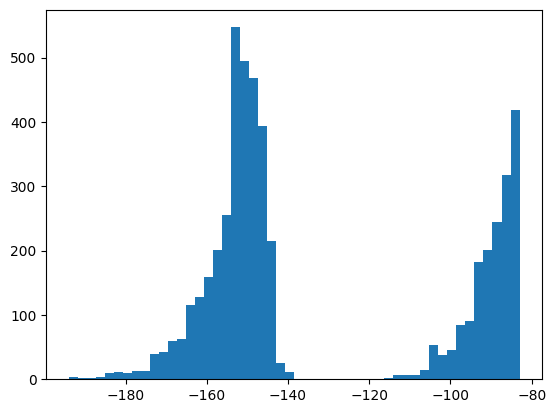

In [34]:
sessions = generate_sessions(5000, agent)
states_batch, actions_batch, rewards_batch = zip(*sessions)
plt.hist(rewards_batch, bins=50);

In [36]:
def save_agent(agent, filename):
    with open(filename, "wb") as f:
        pickle.dump(agent, f)


def load_agent(filename):
    with open(filename, "rb") as f:
        return pickle.load(f)

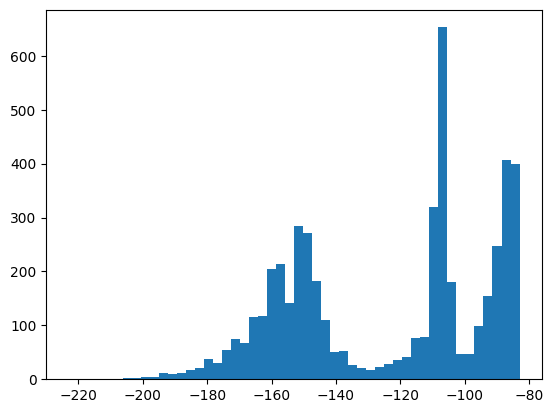

In [38]:
agent2 = load_agent("mountain_car_124.pkl")
sessions_ = generate_sessions(5000, agent2)
_, _, rewards_batch_ = zip(*sessions_)
plt.hist(rewards_batch_, bins=50);

In [41]:
agent = MLPClassifier(
    hidden_layer_sizes=(8, 32, 64, 64, 32, 8),
    activation="relu",
    max_iter=1000,
    warm_start=True,
    solver="adam",
)

agent.fit(elite_states, elite_actions)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(8, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


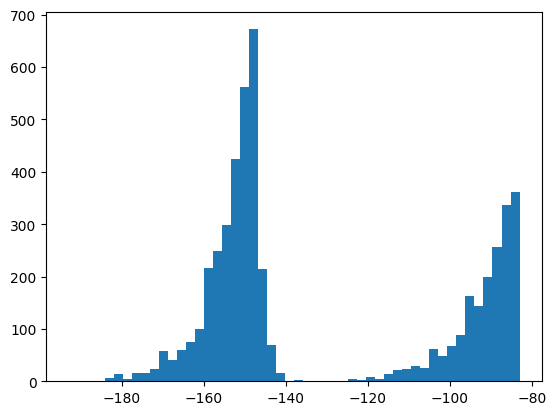

In [42]:
sessions_ = generate_sessions(5000, agent)
states_batch_, actions_batch_, rewards_batch_ = zip(*sessions_)
plt.hist(rewards_batch_, bins=50);

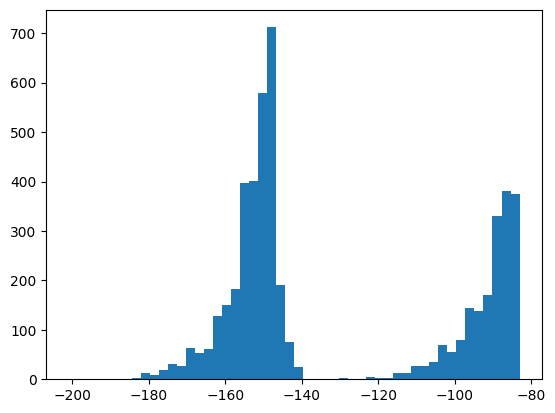

In [43]:
agent_s = MLPClassifier(
    hidden_layer_sizes=(16, 16),
    activation="relu",
    max_iter=1000,
    warm_start=True,
    solver="adam",
)

agent_s.fit(elite_states, elite_actions)

sessions_ = generate_sessions(5000, agent)
states_batch_, actions_batch_, rewards_batch_ = zip(*sessions_)
plt.hist(rewards_batch_, bins=50);

mean reward = -98.891, threshold=-102.000


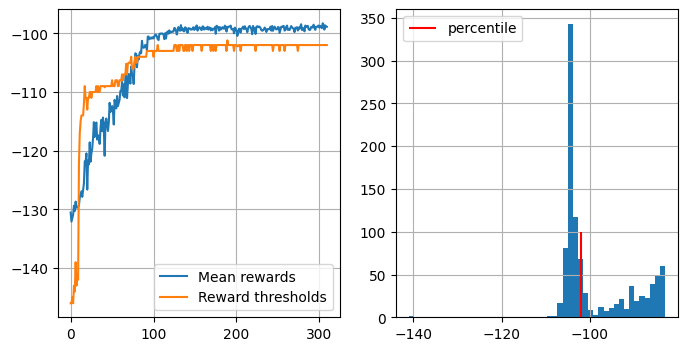

In [45]:
# elite_states_window = []
# elite_actions_window = []
window_size = 8
percentile = 60

agent_s.solver = "adam"
agent_s.learning_rate_init = 0.001
agent_s.max_iter = 1

for _ in range(300):
    sessions = generate_sessions(1000, agent_s)
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    new_elite_states, new_elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, 60
    )
    
    elite_states_window.append(new_elite_states)
    elite_actions_window.append(new_elite_actions)
    elite_states_window = elite_states_window[-window_size:]
    elite_actions_window = elite_actions_window[-window_size:]

    elite_states = sum(elite_states_window, [])
    elite_actions = sum(elite_actions_window, [])
    
    agent_s.partial_fit(elite_states, elite_actions)
    show_progress(rewards_batch, log, 60, reward_range=None)

In [46]:
save_agent(agent_s, "mountain_car_99.pkl")

mean reward = -127.594, threshold=-89.000


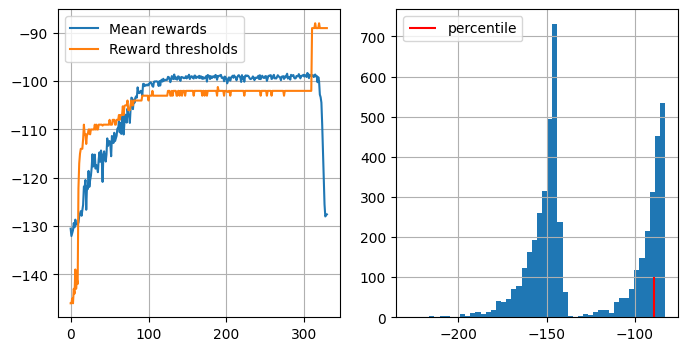

In [47]:
elite_states_window = []
elite_actions_window = []
window_size = 3
percentile = 80

agent_s.solver = "adam"
agent_s.learning_rate_init = 0.0003
agent_s.max_iter = 1

for _ in range(20):
    sessions = generate_sessions(5000, agent_s)
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    new_elite_states, new_elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, percentile
    )
    
    elite_states_window.append(new_elite_states)
    elite_actions_window.append(new_elite_actions)
    elite_states_window = elite_states_window[-window_size:]
    elite_actions_window = elite_actions_window[-window_size:]

    elite_states = sum(elite_states_window, [])
    elite_actions = sum(elite_actions_window, [])
    
    agent_s.partial_fit(elite_states, elite_actions)
    show_progress(rewards_batch, log, percentile, reward_range=None)

mean reward = -115.378, threshold=-86.000


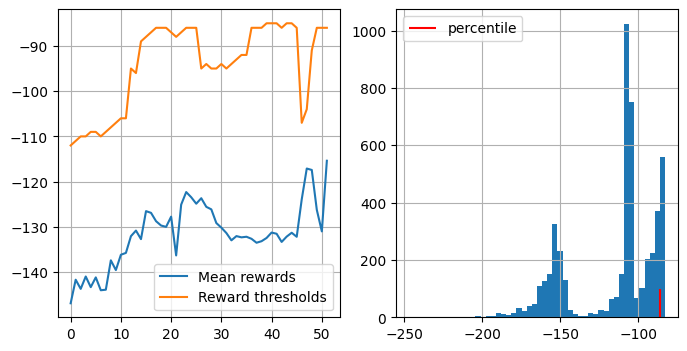

In [76]:
sessions = generate_sessions(5000, agent)
states_batch, actions_batch, rewards_batch = zip(*sessions)
show_progress(rewards_batch, log, 90, reward_range=None)

mean reward = -127.585, threshold=-91.000


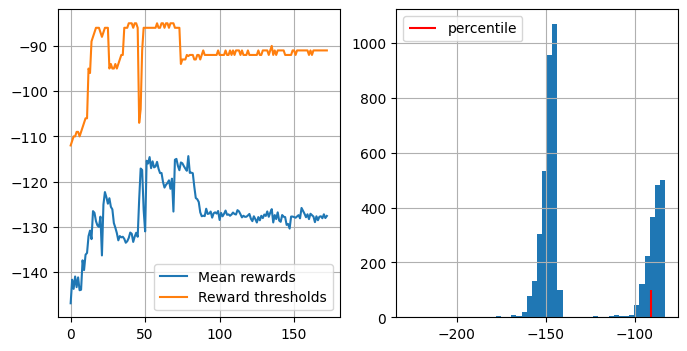

KeyboardInterrupt: 

In [83]:
elite_states = []
elite_actions = []

agent.solver = "sgd"
agent.learning_rate_init = 0.0002
agent.max_iter = 4

for _ in range(100):
    sessions = generate_sessions(5000, agent)
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    new_elite_states, new_elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, 75
    )
    elite_states.extend(new_elite_states)
    elite_actions.extend(new_elite_actions)
    elite_states = elite_states[-len(new_elite_states) * 15:]
    elite_actions = elite_actions[-len(new_elite_actions) * 15:]
    agent.partial_fit(elite_states, elite_actions)
    show_progress(rewards_batch, log, 75, reward_range=None)

In [18]:
import pickle

with open(f"mountain_car_bigger_115.pkl", "wb") as f:
    pickle.dump(agent, f)

mean reward = -126.612, threshold=-85.000


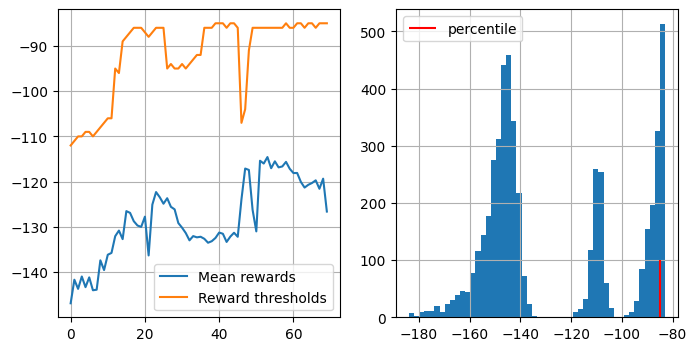

KeyboardInterrupt: 

In [79]:
elite_states = []
elite_actions = []

agent.max_iter = 1

for _ in range(100):
    sessions = generate_sessions(5000, agent)
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    new_elite_states, new_elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, 90
    )
    elite_states.extend(new_elite_states)
    elite_actions.extend(new_elite_actions)
    elite_states = elite_states[-len(new_elite_states) * 5:]
    elite_actions = elite_actions[-len(new_elite_actions) * 5:]
    agent.partial_fit(elite_states, elite_actions)
    show_progress(rewards_batch, log, 90, reward_range=None)

In [ ]:
sessions = generate_sessions(20000, agent)
states_batch, actions_batch, rewards_batch = zip(*sessions)
mean_reward = np.array(rewards_batch).mean()

In [ ]:
import pickle

with open(f"mountain_car_bigger_{mean_reward}.pkl", "wb") as f:
    pickle.dump(agent, f)

In [ ]:
import pickle

with open(f"mountain_car_bigger_{mean_reward}.pkl", "wb") as f:
    pickle.dump(agent, f)

In [66]:
old_log = log[:]
log = log[75:]

In [78]:
import pickle

with open("mountain_car_bigger_115.pkl", "wb") as f:
    pickle.dump(agent, f)

In [63]:
import pickle

with open("mountain_car_124.pkl", "wb") as f:
    pickle.dump(agent, f)

In [31]:
def evaluate(probs_f, n_sessions):
    sessions = [
        generate_session(env, probs_f, t_max=10000)
        for _ in tqdm(range(n_sessions))
    ]
    states_batch, actions_batch, rewards_batch = zip(*sessions)
    elite_states, elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, 0.1
    )
    rewards = np.array(rewards_batch)
    successful_sessions = (rewards > -10000).sum()
    print(
        f"{successful_sessions}/{n_sessions} successful sessions, mean_reward={rewards.mean()}"
    )
    return elite_states, elite_actions

In [32]:
new_elite_states, new_elite_actions = evaluate(get_probs, 100)

  0%|          | 0/100 [00:00<?, ?it/s]

100/100 successful sessions, mean_reward=-1420.56


In [ ]:
# agent.learning_rate_init = 0.001

In [ ]:
# elite_states.extend(new_elite_states)
# elite_actions.extend(new_elite_actions)

In [ ]:
# for _ in range(5):
#     agent.fit(elite_states, elite_actions)

# new_elite_states, new_elite_actions = evaluate(get_probs, 50)
# elite_states.extend(new_elite_states)
# elite_actions.extend(new_elite_actions)

In [ ]:
# for _ in range(5):
#     agent.fit(elite_states, elite_actions)

# new_elite_states, new_elite_actions = evaluate(get_probs, 50)
# elite_states.extend(new_elite_states)
# elite_actions.extend(new_elite_actions)

In [ ]:
# [generate_session(env, get_probs, t_max=10000) for _ in tqdm(range(50))]

In [ ]:
# for _ in range(5):
#     train(agent, get_probs, 100, 0.7)

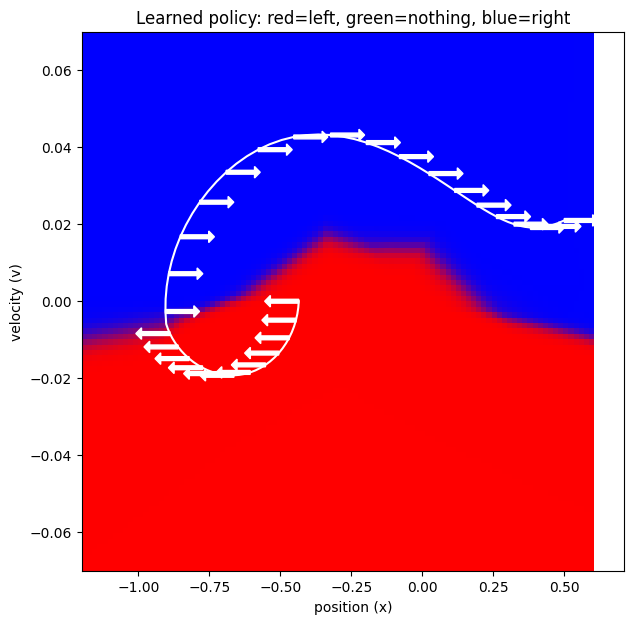

In [49]:
def visualize_mountain_car(env, agent):
    # Compute policy for all possible x and v (with discretization)
    obs_low = env.observation_space.low
    obs_high = env.observation_space.high
    x_min, v_min = obs_low
    x_max, v_max = obs_high

    xs = np.linspace(x_min, x_max, 100)
    vs = np.linspace(v_min, v_max, 100)
    
    grid = np.dstack(np.meshgrid(xs, vs[::-1])).transpose(1, 0, 2)
    grid_flat = grid.reshape(len(xs) * len(vs), 2)
    probs = (
        agent.predict_proba(grid_flat).reshape(len(xs), len(vs), 3).transpose(1, 0, 2)
    )

    # # The above code is equivalent to the following:
    # probs = np.empty((len(vs), len(xs), 3))
    # for i, v in enumerate(vs[::-1]):
    #     for j, x in enumerate(xs):
    #         probs[i, j, :] = agent.predict_proba([[x, v]])[0]

    # Draw policy
    f, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(
        probs,
        extent=(x_min, x_max, v_min, v_max),
        aspect="auto",
    )
    ax.set_title("Learned policy: red=left, green=nothing, blue=right")
    ax.set_xlabel("position (x)")
    ax.set_ylabel("velocity (v)")

    # Sample a trajectory and draw it
    states, actions, _ = generate_session(env, partial(get_probs_, agent_s))
    states = np.array(states)
    ax.plot(states[:, 0], states[:, 1], color="white")

    # Draw every 3rd action from the trajectory
    for (x, v), a in zip(states[::3], actions[::3]):
        if a == 0:
            plt.arrow(x, v, -0.1, 0, color="white", head_length=0.02)
        elif a == 2:
            plt.arrow(x, v, 0.1, 0, color="white", head_length=0.02)


with gym.make("MountainCar-v0", render_mode="rgb_array").env as env:
    visualize_mountain_car(env, agent_s)


### Bonus tasks

* __2.3 bonus__ (2 pts) Try to find a network architecture and training params that solve __both__ environments above (_Points depend on implementation. If you attempted this task, please mention it in Anytask submission._)

* __2.4 bonus__ (4 pts) Solve continuous action space task with `MLPRegressor` or similar.
  * Since your agent only predicts the "expected" action, you will have to add noise to ensure exploration.
  * Choose one of [MountainCarContinuous-v0](https://gymnasium.farama.org/environments/classic_control/mountain_car_continuous/) (90+ pts to solve), [LunarLanderContinuous-v2](https://gymnasium.farama.org/environments/box2d/lunar_lander/) (`env = gym.make("LunarLander-v2", continuous=True)`)(200+ pts to solve)
  * 4 points for solving. Slightly less for getting some results below solution threshold. Note that discrete and continuous environments may have slightly different rules, aside from action spaces.